In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

Information around the tau tissue specificity for isoforms over GTEx tissues 
-
the taaue metric for isoforms was taken from https://genomics.senescence.info/gene_expression/tau.html

In [2]:
#lets look at the tau data
tau = pd.read_csv("applied_depletion_gregor_n100/Tau_transcript_V8.csv")
tau = tau[~tau['tau'].isna()].reset_index(drop=True)  
tau

,transcript_id,tau,Adipose_Tissue,Muscle,Blood_Vessel,Heart,Uterus,Vagina,Breast,Skin,...,Testis,Nerve,Blood,Pituitary,Ovary,Liver,Kidney,Cervix_Uteri,Fallopian_Tube,Bladder
0,ENST00000000233,0.114639,6.515170,5.906236,6.651449,5.473733,6.877312,6.930947,6.606212,7.313729,...,6.769503,6.726857,6.179731,6.742464,6.159855,5.752404,6.297130,6.779944,6.673713,6.580713
1,ENST00000000412,0.137956,4.903210,3.941823,5.092056,3.904555,5.152609,4.692722,4.814483,4.983612,...,5.278947,4.851720,4.528661,4.322665,4.676377,3.327255,3.972765,4.847944,4.992063,5.140545
2,ENST00000000442,0.331060,4.120041,6.181993,3.772968,5.468206,3.320322,4.320397,3.989050,4.288937,...,2.410104,3.329117,3.199989,3.558038,2.258100,4.630014,5.042521,3.561744,3.570193,4.589421
3,ENST00000001008,0.155311,4.539961,4.988017,5.051607,4.016141,5.098287,5.389651,4.776328,5.223033,...,5.835425,5.124996,3.962310,5.136249,5.379288,4.525010,5.037274,5.274046,5.074296,5.387484
4,ENST00000001146,0.645103,3.332351,0.467140,1.435419,0.406264,1.336364,1.256817,2.386937,3.215177,...,2.633331,2.650894,0.000000,2.378884,1.041944,0.000000,1.303920,0.558397,1.788918,0.649013
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
104120,ENST00000640981,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
104121,ENST00000640983,0.993368,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.669278,0.000000,0.000000,0.128718,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
104122,ENST00000640986,0.938472,0.000000,0.000000,0.459223,0.000000,0.267683,0.000000,0.000000,0.100716,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.427351
104123,ENST00000640989,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.274004,0.000000,0.000000,0.000000,0.000000


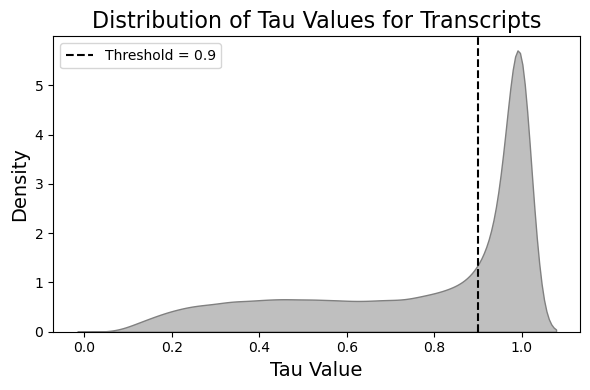

In [4]:
#this is the tissue specificity threshold used to assign uniqueness to tissues
plt.figure(figsize=(6, 4))
sns.kdeplot(tau['tau'], fill=True, color='grey', alpha=0.5)
plt.axvline(0.9, color='black', linestyle='--', label='Threshold = 0.9')
plt.title('Distribution of Tau Values for Transcripts', fontsize=16)
plt.xlabel('Tau Value', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/figures/Tau_distribution_threshold.png', dpi=300)
plt.show()

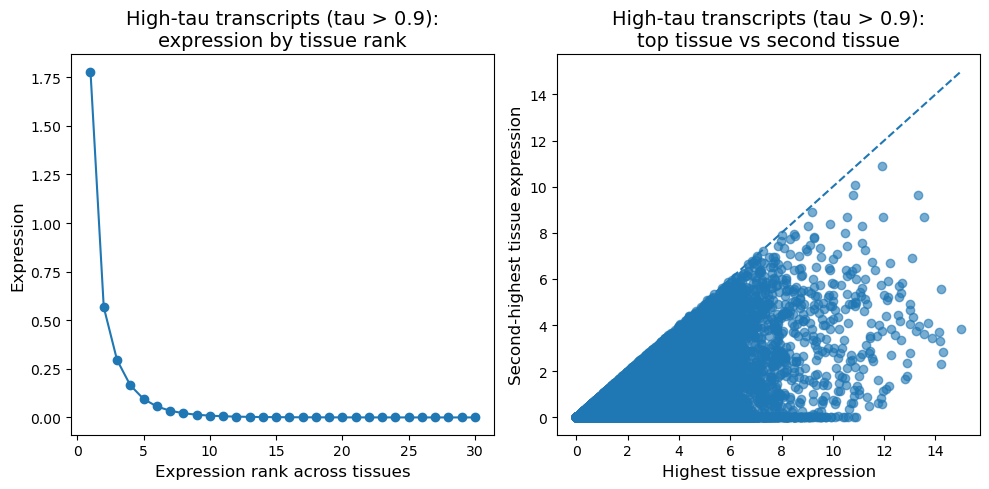

In [9]:

# identify tissue columns
meta_cols = ["transcript_id", "tau"]
tissue_cols = [c for c in tau.columns if c not in meta_cols]

# subset high-tau transcripts
high_tau = tau[tau["tau"] > 0.9].copy()

# get sorted expression values for each transcript
sorted_expr = np.sort(high_tau[tissue_cols].values, axis=1)[:, ::-1]  

# top 1, top 2, top 3
high_tau["expr_rank1"] = sorted_expr[:, 0]
high_tau["expr_rank2"] = sorted_expr[:, 1]
high_tau["expr_rank3"] = sorted_expr[:, 2]

# get tissue identity for top 1 and top 2
top1_tissue = []
top2_tissue = []

for _, row in high_tau[tissue_cols].iterrows():
    s = row.sort_values(ascending=False)
    top1_tissue.append(s.index[0])
    top2_tissue.append(s.index[1])

high_tau["top1_tissue"] = top1_tissue
high_tau["top2_tissue"] = top2_tissue

# -------- plot --------
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Panel A: rank-expression summary
mean_by_rank = sorted_expr.mean(axis=0)
q25_by_rank = np.percentile(sorted_expr, 25, axis=0)
q75_by_rank = np.percentile(sorted_expr, 75, axis=0)
ranks = np.arange(1, len(tissue_cols) + 1)

axes[0].plot(ranks, mean_by_rank, marker="o")
axes[0].set_xlabel("Expression rank across tissues", fontsize=12)
axes[0].set_ylabel("Expression", fontsize=12)
axes[0].set_title("High-tau transcripts (tau > 0.9):\nexpression by tissue rank", fontsize=14)

# Panel B: top1 vs top2 scatter
axes[1].scatter(high_tau["expr_rank1"], high_tau["expr_rank2"], alpha=0.6)
lims = [
    min(high_tau["expr_rank1"].min(), high_tau["expr_rank2"].min()),
    max(high_tau["expr_rank1"].max(), high_tau["expr_rank2"].max())
]
axes[1].plot(lims, lims, linestyle="--")
axes[1].set_xlabel("Highest tissue expression", fontsize=12)
axes[1].set_ylabel("Second-highest tissue expression", fontsize=12)
axes[1].set_title("High-tau transcripts (tau > 0.9):\ntop tissue vs second tissue", fontsize=14)

plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/figures/Tau_top_2_tissues.png', dpi=300)
plt.show()

Assignment 
-
1) In the scatter plot above, many transcripts cluster near the diagonal line, indicating that transcripts with a tau score above 0.9 are not just highly expressed in the primary tissue but also highly expressed in a secondary tissue

2) Because the transcripts with tau > 0.9 are not only highly expressed in 1 tissue, but also highly and uniquely expressed in a second tissue, we will assign the transcript to the top two tissues. 

3) This will ensure comprehensive analysis for tissue enrichment and cast a wider net, specifically capturing more off-target effects. Even though we are removing blood specific trancripts, there could be unique blood transcripts also very highly and uniquely expressed in other tissues like lung, we want to be able to report if we are having a deleterious effect on those tissues as well

In [ ]:
#keep the top 2 tissues for each transcript 
threshold = 0.9
tau = pd.read_csv("applied_depletion_gregor_n100/Tau_transcript_V8.csv")
tau = tau[tau['tau'] > threshold].reset_index(drop=True)
tissue_cols = [c for c in tau.columns if c not in ('transcript_id', 'tau')]

long = (
    tau.melt(
        id_vars=['transcript_id', 'tau'],
        value_vars=tissue_cols,
        var_name='primary_tissue',
        value_name='tissue_score'
    )
    .dropna(subset=['tissue_score'])
)

# remove Testis considering it is an outlier and will skew the downstream analysis
long = long[long['primary_tissue'] != 'Testis']

# for each transcript, take the top 2 tissues by score
top2 = (
    long.groupby('transcript_id', group_keys=False)
        .apply(lambda g: g.nlargest(2, 'tissue_score'))
        .reset_index(drop=True)
)

out = (
    top2.assign(**{'Transcript stable ID': top2['transcript_id']})
        [['Transcript stable ID', 'primary_tissue', 'tissue_score']]
        .reset_index(drop=True)
)

tau = out[['Transcript stable ID', 'primary_tissue']]
# this is what gets input into the statistical enrichment tests 
tau.to_csv("applied_depletion_gregor_n100/Tau_transcript_top2_tissues_above_0.9.csv", index=False)
tau


/var/folders/fv/spz1kmdd6fzcpgwh4n4pgtxh0000gn/T/ipykernel_54077/2902499664.py:23: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.nlargest(2, 'tissue_score'))


,Transcript stable ID,primary_tissue
0,ENST00000002596,Ovary
1,ENST00000002596,Bladder
2,ENST00000003084,Pancreas
3,ENST00000003084,Salivary_Gland
4,ENST00000003583,Brain
...,...,...
104605,ENST00000640986,Bladder
104606,ENST00000640989,Liver
104607,ENST00000640989,Adipose_Tissue
104608,ENST00000640998,Liver


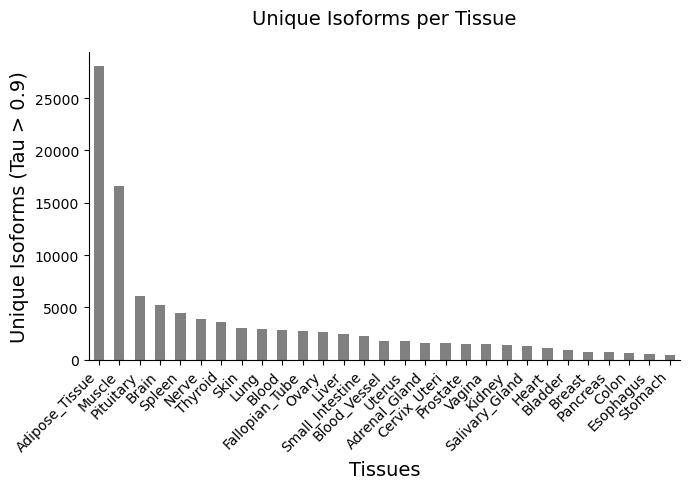

In [15]:
# final tau metrics 
counts = pd.DataFrame(tau['primary_tissue'].value_counts())
counts['tissue']=counts.index
fig, ax = plt.subplots(figsize=(7, 5))
counts.plot(kind='bar', x='tissue', y='count', ax=ax, color='grey')

ax.set_xlabel("Tissues", fontsize=14)
ax.set_ylabel("Unique Isoforms (Tau > 0.9)", fontsize=14)
ax.set_title("Unique Isoforms per Tissue", fontsize=14, pad=20)


ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.legend().set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('applied_depletion_gregor_n100/figures/Tau_isoforms_per_tissue.png',dpi=300)
plt.show()